# 1 Module, Globals und Daten

## 1.1 Module

In [ ]:
##### IMPORTS #####
import matplotlib.pyplot as pyplot
import pandas as pd
from sklearn.model_selection import train_test_split
import sklearn.metrics as skm
import xgboost as xgb
from xgboost import XGBClassifier


## 1.2 Globals

In [ ]:
##### Globals #####
dataPath = 'datasets/gyro/'                         # Set location of dataset


## 1.3 Daten

In [4]:
##### Data Import and Splitting #####
data = pd.read_csv(dataPath + 'gyro_mobile.csv')    # Dataset is imbalanced with only ~1.7% of all labels being 0's
data = data.drop(columns='timestamp')
xdata = data.iloc[:,:6]
ydata = data.iloc[:,6:]

xtrain, xtest, ytrain, ytest = train_test_split( 
    xdata,
    ydata,
    random_state=0,
    train_size=0.33,
    stratify=ydata                                  # Preserve label imbalance across train- and test datasets
)

evalset = [(xtrain,ytrain),(xtest,ytest)]

# 2 Modell

## 2.1 Training

In [ ]:
model = XGBClassifier(
    objective = "binary:logistic"
)

### 2.2.2 Naive Evaluation

Accuracy Score: 		0.9833442194644023
Balanced Accuracy-Score: 	0.586493537452808

              precision    recall  f1-score   support

 0: standing       0.62      0.17      0.27       383
  1: walking       0.99      1.00      0.99     21051

    accuracy                           0.98     21434
   macro avg       0.80      0.59      0.63     21434
weighted avg       0.98      0.98      0.98     21434



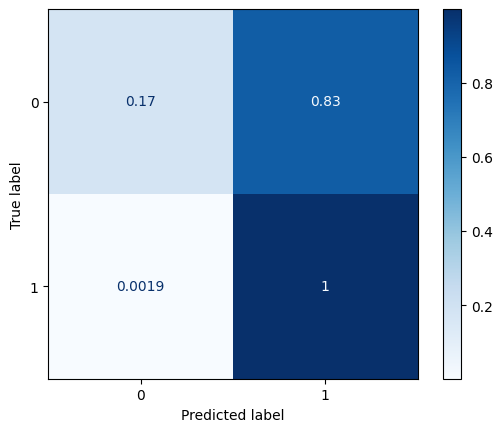

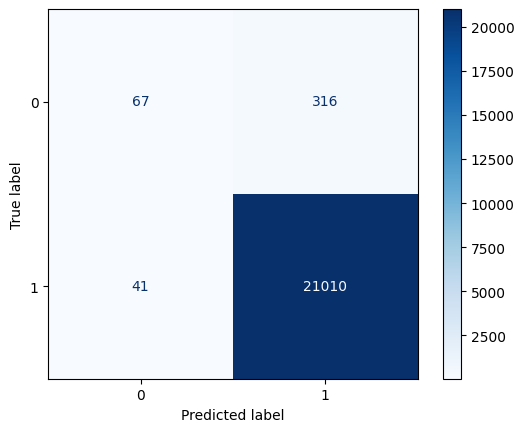

In [ ]:
model.set_params(tree_method = 'exact')
model.fit(xtrain, ytrain,
          eval_set=evalset,
          verbose = 0)

##### Predictions and Accuracy #####
yhat = model.predict(xtest)

print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
print()
print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', normalize='true')
pyplot.title('')
pyplot.show()

skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap="Blues" ,values_format='d')
# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
pyplot.show()

### 2.2.3 Adjusted for Imbalance

[XGBoost for Imbalanced Classification](https://xgboosting.com/xgboost-scale_pos_weight-vs-sample_weight-for-imbalanced-classification/)

Accuracy Score: 		0.958803769711673
Balanced Accuracy-Score: 	0.8290645756116595

              precision    recall  f1-score   support

 0: standing       0.26      0.69      0.38       383
  1: walking       0.99      0.96      0.98     21051

    accuracy                           0.96     21434
   macro avg       0.63      0.83      0.68     21434
weighted avg       0.98      0.96      0.97     21434



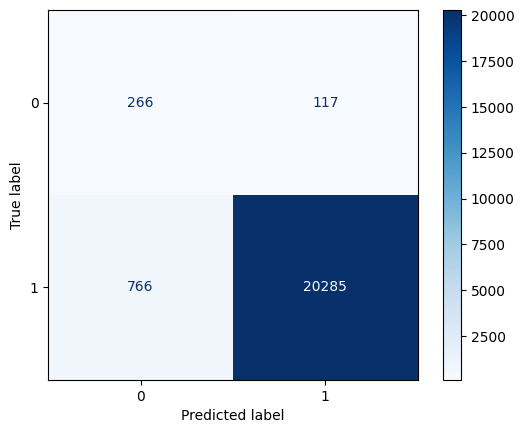

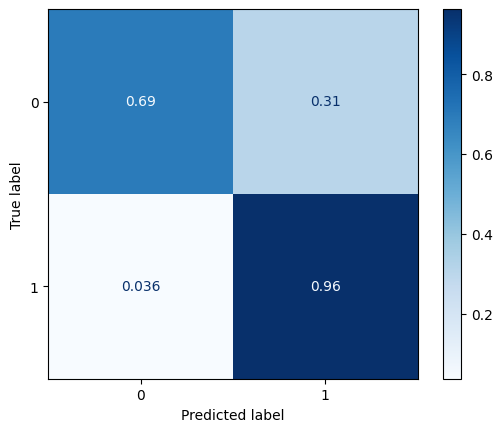

In [ ]:
model.set_params(    
    tree_method = 'exact',
    scale_pos_weight = len(data[data['Activity']==0]) / len(data[data['Activity']==1]), # Increase weight of minority class                                                             # Limit the maximum change in the predictions)
)

model.fit(xtrain,ytrain,
          eval_set=evalset,
          verbose = 0)

yhat = model.predict(xtest)

print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
print()
print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
pyplot.show()
skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', normalize='true')
pyplot.show()

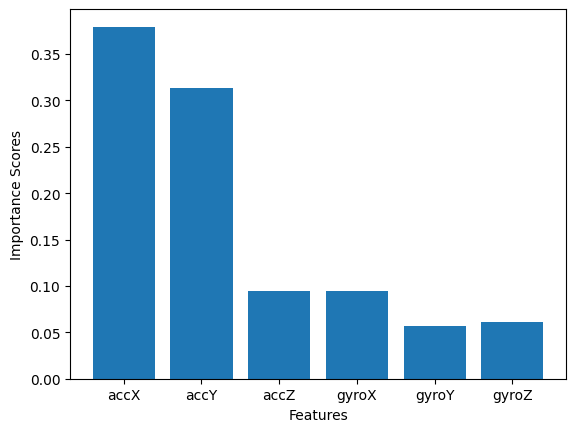

In [ ]:
fig,ax = pyplot.subplots()

iScores = model.feature_importances_
fNames = model.feature_names_in_

ax.bar(fNames, iScores)

ax.set_ylabel("Importance Scores")
ax.set_xlabel("Features")

pyplot.show()

# Sonstiges/Eingestellt

## Skalierung der Daten

Es wurde neben dem eigentlichem Datensatz auch Modell mit einem Datensatz trainiert, bei dem die Daten nicht skaliert worden sind.
Die daraus resultierende Accuracy war identisch mit der unskalierten Version.


In [ ]:
# ##### Scaled comparison #####

# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# xdata_scaled = scaler.fit_transform(xdata)

# xtrain_scaled, xtest_scaled, ytrain_scaled, ytest_scaled = train_test_split( 
#     xdata_scaled,
#     ydata,
#     random_state=0,
#     stratify=ydata                                  # Preserve label imbalance across train- and test datasets
# )

# model_scaled = XGBClassifier(
#     objective='binary:logistic'
# )
# model_scaled.fit(xtrain_scaled,ytrain)

# yhat_scaled = model_scaled.predict(xtest_scaled)
# print(accuracy_score(ytest_scaled, yhat_scaled))    # 0.9834958739684921

## C-Reports und C-Matrizen für unterschiedliche Tree_Methods

### Raw

In [ ]:
# model.set_params(tree_method = 'approx')
# model.fit(xtrain, ytrain,
#           eval_set=evalset,
#           verbose = 0)

# ##### Predictions and Accuracy #####
# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
# print()
# print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
# pyplot.show()


In [ ]:
# model.set_params(tree_method = 'hist')
# model.fit(xtrain, ytrain,
#           eval_set=evalset,
#           verbose = 0)

# ##### Predictions and Accuracy #####
# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
# print()
# print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
# pyplot.show()

### Angepasst

In [ ]:
# model.set_params(    
#     tree_method = 'approx',
#     scale_pos_weight = len(data[data['Activity']==0]) / len(data[data['Activity']==1]), # Increase weight of minority class
#     max_delta_step = 1                                                                  # Limit the maximum change in the predictions)
# )

# model.fit(xtrain,ytrain,
#           eval_set=evalset,
#           verbose = 0)

# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
# print()
# print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
# pyplot.show()


In [ ]:
# model.set_params(    
#     tree_method = 'hist',
#     scale_pos_weight = len(data[data['Activity']==0]) / len(data[data['Activity']==1]), # Increase weight of minority class
#     max_delta_step = 0
# )

# model.fit(xtrain,ytrain,
#           eval_set=evalset,
#           verbose = 0)

# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          # 0.9828310161425772 stratified | 0.981664644956611  naive  | 0.9534384622562284 scale_pos_weight = len(0s)/len(1s)
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}') # 0.5990495790838934 stratified | 0.5770402535045962 naive  | 0.8314600386751905 scale_pos_weight = len(0s)/len(1s)
# print()
# print(skm.classification_report(ytest,yhat, labels=[0,1], target_names=['0: standing','1: walking']))

# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', values_format='d')
# pyplot.show()


### Validieren, dass tree_method "auto" == "hist"

In [ ]:
# model = XGBClassifier()
# model.set_params(tree_method = 'auto',
#                  objective = "binary:logistic",
#                  scale_pos_weight = len(data[data['Activity']==0]) / len(data[data['Activity']==1]))
# model.fit(xtrain, ytrain)

# yhat = model.predict(xtest)

# print(f'Accuracy Score: \t\t{skm.accuracy_score(ytest, yhat)}')          
# print(f'Balanced Accuracy-Score: \t{skm.balanced_accuracy_score(ytest, yhat)}')

# # Accuracy Score: 		    0.9534384622562284
# # Balanced Accuracy-Score: 	0.8314600386751905

# C-Matrix Optionen

In [ ]:
# Gibt das Verhältnis von richtig und falsch bzgl. einer Vorhersage an
# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', normalize='pred')
# pyplot.title('Normalize = Pred')
# pyplot.show()

# Gibt das Verhältnis der jeweiligen TP/FP/TN/FN aus allen Vorhersagen an
# skm.ConfusionMatrixDisplay.from_estimator(model, xtest, ytest, cmap='Blues', normalize='all')
# pyplot.title('Normalize = All')
# pyplot.show()